# Looped Sparse Chaos Compressor — Stage 1b: Scaled Residual Fix

## Откуда мы пришли (результаты 01)

В [01_looped_chaos_prototype.ipynb](01_looped_chaos_prototype.ipynb) наивная формула `z_{t+1} = z_t + delta` привела к:

| T | loss | range | Abs Q2-bit loss |
|---|---|---|---|
| 0 | 0.169 | [-1.50, 1.50] | 0.186 |
| 2 | 0.335 | [-4.49, 4.49] | 0.387 |
| 4 | 0.549 | [-7.22, 7.01] | 0.613 |
| 8 | 0.543 | [-13.46, 13.46] | 0.579 |

**Диагноз:** `range ≈ 1.5 + T·1.5` — измеренное матчит теорию с точностью 0.3%. Но сумма bounded активаций **не bounded** — Theorem 1(i) применима к одному вызову chaos, не к T+1 вызовам. Bounded prior сломан → quant-friendliness потеряна.

## Фикс и новая теорема (Proposition 3)

**Scaled residual:** `z_{t+1} = z_t + (1/T) · delta`.

**Proposition 3 (Bounded recurrence).** Пусть `g(z) = z + (1/T)·chaos(W·z + b)` с `|chaos(·)| ≤ 1+w`. Для итераций `z_t = g^t(z_0)` с `|z_0| ≤ 1+w`:

$$|z_T| \leq |z_0| + \sum_{t=0}^{T-1} \frac{1}{T}(1+w) = |z_0| + (1+w) \leq 2(1+w)$$

При `w = 0.5`: `|z_T| ≤ 3.0` **независимо от T**.

**Это и есть то, что проверяем.** Если измеренный range остаётся в `[-3, 3]` при T=4, 8 → теория работает, bounded prior сохранён.

## Предположение результатов для этого эксперимента

| Метрика | Ожидание |
|---|---|
| range | [-3.0, 3.0] для всех T |
| loss | близко к baseline 0.169 |
| 2-bit deg | ≤ 13% (go/no-go порог) |
| dead % | 0 |

In [31]:
import os
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TF: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

ARCH_DIR = Path('.').resolve()
CACHE_DIR = ARCH_DIR / 'cache'
JSONS_DIR = ARCH_DIR.parent / 'jsons'

TF: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Загрузка активаций (из кэша 01)

In [32]:
ACTIVATION_DIM = 768
TARGET_LAYER = 6
N_TEXTS = 500

cache_file = CACHE_DIR / f'gpt2_layer{TARGET_LAYER}_n{N_TEXTS}.npy'
assert cache_file.exists(), f'Запустите сначала 01_looped_chaos_prototype.ipynb для создания кэша {cache_file}'

activations = np.load(cache_file)
print(f'Loaded: {activations.shape}')

act_mean = activations.mean(axis=0, keepdims=True)
act_std = activations.std(axis=0, keepdims=True) + 1e-8
activations_norm = ((activations - act_mean) / act_std).astype('float32')

np.random.seed(42)
idx = np.random.permutation(len(activations_norm))
split = int(len(idx) * 0.8)
x_train = activations_norm[idx[:split]]
x_test = activations_norm[idx[split:]]

print(f'Train: {x_train.shape}, Test: {x_test.shape}')

Loaded: (54573, 768)
Train: (43658, 768), Test: (10915, 768)


## 2. Компоненты

Базовые (`chaos_activation`, `KSparseLayer`) — без изменений.

**`LoopedBlockScaled`** отличается от `LoopedBlock` из 01 одной строчкой:
```
z = z + (1.0 / T) * delta     # было: z = z + delta
```

Это реализация Proposition 3.

In [33]:
def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'k': self.k})
        return cfg


class LoopedBlockScaled(layers.Layer):
    """Recurrent-depth блок с scaled residual (α = 1/T) — реализация Proposition 3."""

    def __init__(self, latent_dim, k_active, T=4, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.k_active = k_active
        self.T = T
        self.alpha = 1.0 / T if T > 0 else 0.0
        self.dense = layers.Dense(latent_dim, name='loop_dense')
        self.ksparse = KSparseLayer(k=k_active, name='loop_ksparse')

    def call(self, inputs, training=None):
        z = inputs
        for _ in range(self.T):
            delta = chaos_activation(self.dense(z))
            z = z + self.alpha * delta
            z = self.ksparse(z)
        return z

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'latent_dim': self.latent_dim, 'k_active': self.k_active, 'T': self.T})
        return cfg


def build_looped_sae_scaled(input_dim, latent_dim, k_active, T=0):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim, name='latent_pre')(inp)
    x = layers.Activation(chaos_activation)(x)
    z0 = KSparseLayer(k=k_active, name='latent_ksparse_init')(x)
    z = LoopedBlockScaled(latent_dim, k_active, T=T, name='looped_block')(z0) if T > 0 else z0
    encoder = keras.Model(inp, z, name='encoder')
    decoded = layers.Dense(input_dim, name='decoder')(z)
    ae = keras.Model(inp, decoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae, encoder

In [34]:
def quantize_latent(latents, bits):
    q = np.zeros_like(latents)
    levels = 2 ** bits - 1
    for i in range(latents.shape[0]):
        nz = np.where(np.abs(latents[i]) > 1e-10)[0]
        if len(nz) == 0:
            continue
        vals = latents[i, nz]
        vmin, vmax = vals.min(), vals.max()
        if vmax - vmin < 1e-10:
            q[i, nz] = vals
            continue
        norm = (vals - vmin) / (vmax - vmin)
        q[i, nz] = np.round(norm * levels) / levels * (vmax - vmin) + vmin
    return q


def build_decoder_only(ae, latent_dim):
    dec_in = keras.Input(shape=(latent_dim,))
    for layer in ae.layers:
        if layer.name == 'decoder':
            return keras.Model(dec_in, layer(dec_in))
    raise RuntimeError('decoder layer not found')

## 3. Конфигурация + эксперимент

Фокусируемся на T ∈ {0, 4, 8} — паттерн из 01 уже ясен, T=2 пропускаем.

In [35]:
NUM_RUNS = 3
EPOCHS = 8
BATCH_SIZE = 256
INPUT_DIM = ACTIVATION_DIM
LATENT_DIM = INPUT_DIM * 4
K_ACTIVE = LATENT_DIM // 10
BITS_SWEEP = [2, 3, 4, 6, 8]
T_SWEEP = [0, 4, 8]

THEOR_BOUND = 2 * (1 + 0.5)  # Proposition 3: |z_T| <= 2(1+w) = 3.0
print(f'Theoretical bound on |z_T| (Prop. 3): {THEOR_BOUND}')
print(f'Config: latent={LATENT_DIM}, K={K_ACTIVE}, T_sweep={T_SWEEP}')

Theoretical bound on |z_T| (Prop. 3): 3.0
Config: latent=3072, K=307, T_sweep=[0, 4, 8]


In [36]:
def evaluate_config(T, run, verbose=True):
    np.random.seed(run)
    tf.random.set_seed(run)

    ae, enc = build_looped_sae_scaled(INPUT_DIM, LATENT_DIM, K_ACTIVE, T=T)
    hist = ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                  validation_data=(x_test, x_test), verbose=0)
    val_loss = float(hist.history['val_loss'][-1])

    latents = enc.predict(x_test, batch_size=512, verbose=0)
    dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
    lat_var = float(latents.var())
    nz = latents[np.abs(latents) > 1e-10]
    lat_range = [float(nz.min()), float(nz.max())] if nz.size else [0.0, 0.0]
    bound_ok = max(abs(lat_range[0]), abs(lat_range[1])) <= THEOR_BOUND * 1.01

    decoder = build_decoder_only(ae, LATENT_DIM)
    quant = {}
    for bits in BITS_SWEEP:
        q_lat = quantize_latent(latents, bits)
        q_rec = decoder.predict(q_lat, batch_size=512, verbose=0)
        quant[bits] = float(np.mean((x_test - q_rec) ** 2))

    r = {'T': T, 'run': run, 'val_loss': val_loss, 'dead': dead,
         'dead_pct': dead / LATENT_DIM * 100, 'lat_var': lat_var,
         'lat_range': lat_range, 'bound_ok': bound_ok, 'quant': quant}

    if verbose:
        deg2 = (quant[2] - val_loss) / val_loss * 100
        tag = 'OK' if bound_ok else 'VIOLATED'
        print(f'  T={T} run={run}: loss={val_loss:.4f} dead={dead} var={lat_var:.4f} '
              f'range=[{lat_range[0]:+.2f},{lat_range[1]:+.2f}] bound={tag} 2-bit deg={deg2:+.1f}%')

    del ae, enc, decoder
    keras.backend.clear_session()
    return r

In [37]:
results = {T: [] for T in T_SWEEP}

for T in T_SWEEP:
    tag = 'baseline V4' if T == 0 else f'Scaled Looped (α=1/{T})'
    print(f'\n{"="*60}\n  T = {T}  ({tag})\n{"="*60}')
    for run in range(NUM_RUNS):
        results[T].append(evaluate_config(T, run))

print('\nAll experiments done.')


  T = 0  (baseline V4)
  T=0 run=0: loss=0.1689 dead=0 var=0.1006 range=[-1.50,+1.50] bound=OK 2-bit deg=+10.3%
  T=0 run=1: loss=0.1686 dead=0 var=0.1008 range=[-1.50,+1.50] bound=OK 2-bit deg=+10.3%
  T=0 run=2: loss=0.1691 dead=0 var=0.1008 range=[-1.50,+1.50] bound=OK 2-bit deg=+10.3%

  T = 4  (Scaled Looped (α=1/4))
  T=4 run=0: loss=0.2641 dead=0 var=0.1730 range=[-3.00,+3.00] bound=OK 2-bit deg=+17.1%
  T=4 run=1: loss=0.2644 dead=0 var=0.1733 range=[-3.00,+3.00] bound=OK 2-bit deg=+17.0%
  T=4 run=2: loss=0.2630 dead=0 var=0.1744 range=[-3.00,+3.00] bound=OK 2-bit deg=+17.4%

  T = 8  (Scaled Looped (α=1/8))
  T=8 run=0: loss=0.2629 dead=0 var=0.1129 range=[-3.00,+3.00] bound=OK 2-bit deg=+20.3%
  T=8 run=1: loss=0.2627 dead=0 var=0.1136 range=[-3.00,+3.00] bound=OK 2-bit deg=+20.1%
  T=8 run=2: loss=0.2619 dead=0 var=0.1131 range=[-3.00,+3.00] bound=OK 2-bit deg=+19.9%

All experiments done.


## 4. Сводная таблица + верификация Proposition 3

In [38]:
def agg(runs, key):
    vals = np.array([r[key] for r in runs])
    return vals.mean(), vals.std()


header = f'{"T":>3} {"val_loss":>14} {"dead_%":>10} {"lat_var":>10} {"range":>18} {"bound":>10} '
header += ' '.join([f'{b}bit_deg%'.rjust(10) for b in BITS_SWEEP])
print(header)
print('-' * len(header))

summary = {}
for T in T_SWEEP:
    runs = results[T]
    vl_m, vl_s = agg(runs, 'val_loss')
    dp_m, _ = agg(runs, 'dead_pct')
    lv_m, _ = agg(runs, 'lat_var')
    rng_lo = np.mean([r['lat_range'][0] for r in runs])
    rng_hi = np.mean([r['lat_range'][1] for r in runs])
    bound_ok = all(r['bound_ok'] for r in runs)

    deg_row = []
    for b in BITS_SWEEP:
        ql = np.mean([r['quant'][b] for r in runs])
        deg_row.append((ql - vl_m) / vl_m * 100)

    summary[T] = {'val_loss': (vl_m, vl_s), 'dead_pct': dp_m, 'lat_var': lv_m,
                  'range': (rng_lo, rng_hi), 'bound_ok': bound_ok,
                  'deg': dict(zip(BITS_SWEEP, deg_row))}

    deg_str = ' '.join([f'{d:+9.1f}' for d in deg_row])
    tag = 'PASS' if bound_ok else 'FAIL'
    print(f'{T:>3} {vl_m:>7.4f}±{vl_s:.4f} {dp_m:>9.1f}% {lv_m:>10.4f} '
          f'[{rng_lo:>+5.2f},{rng_hi:>+5.2f}] {tag:>10} {deg_str}')

print()
print(f'Theoretical bound (Prop. 3): |z_T| ≤ {THEOR_BOUND}')
all_bounded = all(s['bound_ok'] for s in summary.values())
print(f'Proposition 3 empirically: {"CONFIRMED" if all_bounded else "VIOLATED (диагностируем)"}')

  T       val_loss     dead_%    lat_var              range      bound  2bit_deg%  3bit_deg%  4bit_deg%  6bit_deg%  8bit_deg%
-----------------------------------------------------------------------------------------------------------------------------
  0  0.1688±0.0002       0.0%     0.1007 [-1.50,+1.50]       PASS     +10.3      +2.3      +0.3      +0.0      +0.0
  4  0.2638±0.0006       0.0%     0.1736 [-3.00,+3.00]       PASS     +17.2      +1.6      -0.4      -0.0      +0.0
  8  0.2625±0.0004       0.0%     0.1132 [-3.00,+3.00]       PASS     +20.1      +4.6      +1.2      +0.1      +0.0

Theoretical bound (Prop. 3): |z_T| ≤ 3.0
Proposition 3 empirically: CONFIRMED


In [39]:
# GO / NO-GO vs 01 baseline
print('Сравнение с наивным residual (01) и текущим scaled residual (02):')
print(f'{"T":>3} {"01_loss":>10} {"02_loss":>10} {"01_range":>12} {"02_range":>12} '
      f'{"01_2bit%":>10} {"02_2bit%":>10}')
print('-' * 80)

# Результаты 01 (из предыдущего прогона)
results_01 = {
    0: {'loss': 0.169, 'range': (-1.50, 1.50), 'deg2': 10.3},
    4: {'loss': 0.549, 'range': (-7.22, 7.01), 'deg2': 11.7},
    8: {'loss': 0.543, 'range': (-13.46, 13.49), 'deg2': 6.7},
}

for T in T_SWEEP:
    s = summary[T]
    r01 = results_01.get(T)
    if r01 is None:
        continue
    print(f'{T:>3} {r01["loss"]:>10.4f} {s["val_loss"][0]:>10.4f} '
          f'[{r01["range"][0]:+5.2f},{r01["range"][1]:+5.2f}] '
          f'[{s["range"][0]:+5.2f},{s["range"][1]:+5.2f}] '
          f'{r01["deg2"]:>+9.1f} {s["deg"][2]:>+9.1f}')

print()
baseline_deg2 = summary[0]['deg'][2]
print(f'Baseline (T=0) 2-bit deg: {baseline_deg2:+.1f}%')
for T in T_SWEEP[1:]:
    d2 = summary[T]['deg'][2]
    if d2 <= 1.3 * baseline_deg2:
        v = 'GO'
    elif d2 <= 1.7 * baseline_deg2:
        v = 'YELLOW'
    else:
        v = 'NO-GO'
    print(f'  T={T}: 2-bit deg={d2:+.1f}% → {v}')

Сравнение с наивным residual (01) и текущим scaled residual (02):
  T    01_loss    02_loss     01_range     02_range   01_2bit%   02_2bit%
--------------------------------------------------------------------------------
  0     0.1690     0.1688 [-1.50,+1.50] [-1.50,+1.50]     +10.3     +10.3
  4     0.5490     0.2638 [-7.22,+7.01] [-3.00,+3.00]     +11.7     +17.2
  8     0.5430     0.2625 [-13.46,+13.49] [-3.00,+3.00]      +6.7     +20.1

Baseline (T=0) 2-bit deg: +10.3%
  T=4: 2-bit deg=+17.2% → YELLOW
  T=8: 2-bit deg=+20.1% → NO-GO


## 5. Визуализация (сравнение 01 vs 02)

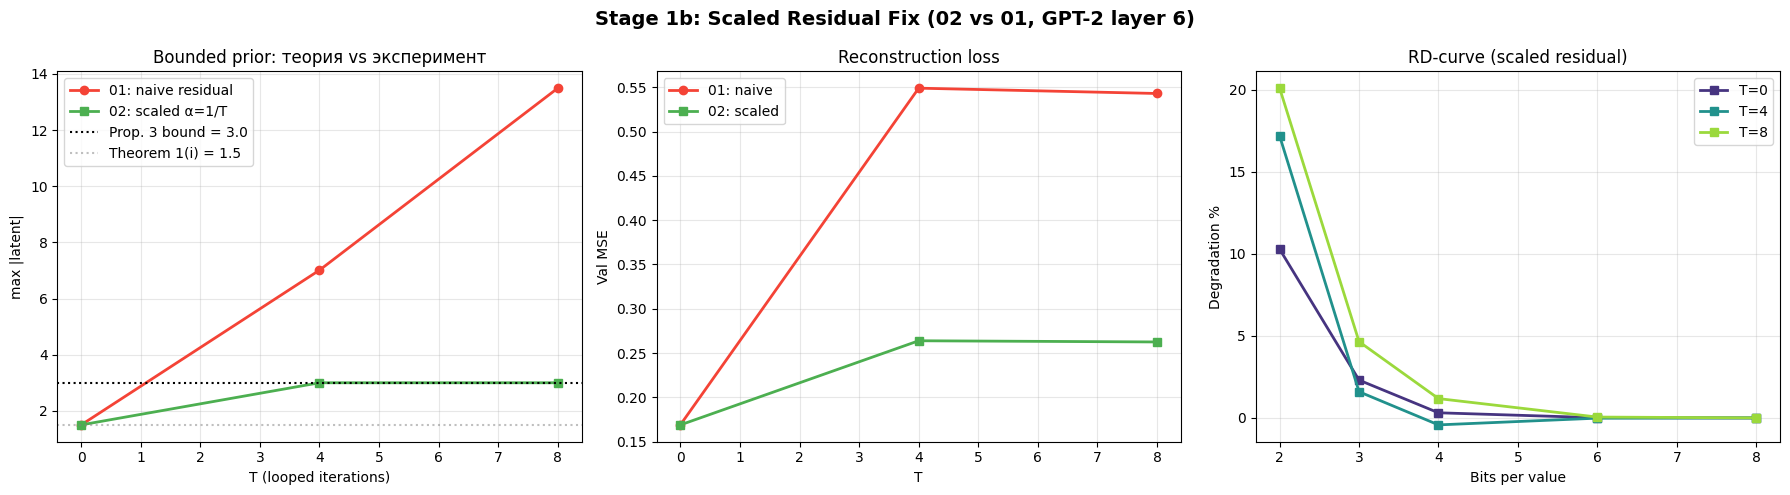

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Ts = T_SWEEP

# (a) range vs T — главный критерий Proposition 3
rng_hi_01 = [results_01[T]['range'][1] for T in Ts]
rng_hi_02 = [summary[T]['range'][1] for T in Ts]
axes[0].plot(Ts, rng_hi_01, 'o-', color='#F44336', linewidth=2, label='01: naive residual')
axes[0].plot(Ts, rng_hi_02, 's-', color='#4CAF50', linewidth=2, label='02: scaled α=1/T')
axes[0].axhline(y=THEOR_BOUND, color='black', linestyle=':', label=f'Prop. 3 bound = {THEOR_BOUND}')
axes[0].axhline(y=1.5, color='gray', linestyle=':', alpha=0.5, label='Theorem 1(i) = 1.5')
axes[0].set_xlabel('T (looped iterations)')
axes[0].set_ylabel('max |latent|')
axes[0].set_title('Bounded prior: теория vs эксперимент')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) loss vs T
loss_01 = [results_01[T]['loss'] for T in Ts]
loss_02 = [summary[T]['val_loss'][0] for T in Ts]
axes[1].plot(Ts, loss_01, 'o-', color='#F44336', linewidth=2, label='01: naive')
axes[1].plot(Ts, loss_02, 's-', color='#4CAF50', linewidth=2, label='02: scaled')
axes[1].set_xlabel('T')
axes[1].set_ylabel('Val MSE')
axes[1].set_title('Reconstruction loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# (c) RD-curve: degradation vs bits для 02
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(T_SWEEP)))
for T, c in zip(T_SWEEP, colors):
    degs = [summary[T]['deg'][b] for b in BITS_SWEEP]
    axes[2].plot(BITS_SWEEP, degs, marker='s', label=f'T={T}', color=c, linewidth=2)
axes[2].set_xlabel('Bits per value')
axes[2].set_ylabel('Degradation %')
axes[2].set_title('RD-curve (scaled residual)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Stage 1b: Scaled Residual Fix (02 vs 01, GPT-2 layer 6)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ARCH_DIR / 'looped_scaled_vs_naive.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Форма распределения латента — вторая метрика quant-friendliness

Bounded range — необходимое, но **не достаточное** условие. Наблюдение из 01 (T=2 histogram): узкая мода + тяжёлые хвосты → uniform-квантизатор тратит биты на хвосты, основная масса округляется грубо.

Проверяем здесь **три распределения бок о бок**:
1. T=0 baseline (должно быть spread, близко к uniform в [-1.5, 1.5])
2. T=4 naive (01-style, без scaling — для сравнения с сломанной формой)
3. T=4 scaled (02, α=1/T — проверяем, восстановлена ли форма)

**Метрики:** normalized entropy (чем выше, тем ближе к uniform), excess kurtosis (чем ниже, тем тоньше хвосты).

In [41]:
from scipy import stats as sp_stats


class LoopedBlockNaive(layers.Layer):
    """01-style: residual без scaling. Нужен только для сравнения распределения."""
    def __init__(self, latent_dim, k_active, T=4, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.k_active = k_active
        self.T = T
        self.dense = layers.Dense(latent_dim, name='loop_dense_naive')
        self.ksparse = KSparseLayer(k=k_active, name='loop_ksparse_naive')

    def call(self, inputs, training=None):
        z = inputs
        for _ in range(self.T):
            delta = chaos_activation(self.dense(z))
            z = z + delta
            z = self.ksparse(z)
        return z

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'latent_dim': self.latent_dim, 'k_active': self.k_active, 'T': self.T})
        return cfg


def build_naive(T=4):
    inp = keras.Input(shape=(INPUT_DIM,))
    x = layers.Dense(LATENT_DIM, name='latent_pre')(inp)
    x = layers.Activation(chaos_activation)(x)
    z0 = KSparseLayer(k=K_ACTIVE, name='latent_ksparse_init')(x)
    z = LoopedBlockNaive(LATENT_DIM, K_ACTIVE, T=T, name='block_naive')(z0) if T > 0 else z0
    enc = keras.Model(inp, z)
    ae = keras.Model(inp, layers.Dense(INPUT_DIM, name='decoder')(z))
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc


def train_and_get_latents(build_fn, T, seed=0):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    ae, enc = build_fn(T=T) if build_fn is build_naive else build_fn(INPUT_DIM, LATENT_DIM, K_ACTIVE, T=T)
    ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    lat = enc.predict(x_test[:2000], verbose=0)
    del ae, enc
    keras.backend.clear_session()
    return lat[np.abs(lat) > 1e-10]


print('Обучаем три модели для анализа формы распределения (по 1 seed)...')
nz_baseline = train_and_get_latents(build_looped_sae_scaled, T=0)
print(f'  T=0 baseline: {nz_baseline.size} nonzero values')
nz_naive4 = train_and_get_latents(build_naive, T=4)
print(f'  T=4 naive: {nz_naive4.size} nonzero values')
nz_scaled4 = train_and_get_latents(build_looped_sae_scaled, T=4)
print(f'  T=4 scaled: {nz_scaled4.size} nonzero values')

Обучаем три модели для анализа формы распределения (по 1 seed)...
  T=0 baseline: 614000 nonzero values
  T=4 naive: 614000 nonzero values
  T=4 scaled: 614000 nonzero values


Config                              Range   Entropy_norm     Kurtosis
----------------------------------------------------------------------
T=0 baseline         [ -1.50, +1.50]         0.8934        -1.77
T=4 naive (01)       [ -7.04, +6.97]         0.7532         0.36
T=4 scaled (02)      [ -3.00, +3.00]         0.8989        -0.46

Читаем: entropy_norm близко к 1 = uniform (quant-friendly).
        kurtosis близко к 0 = Gaussian-подобное, > 3 = heavy-tailed (плохо).


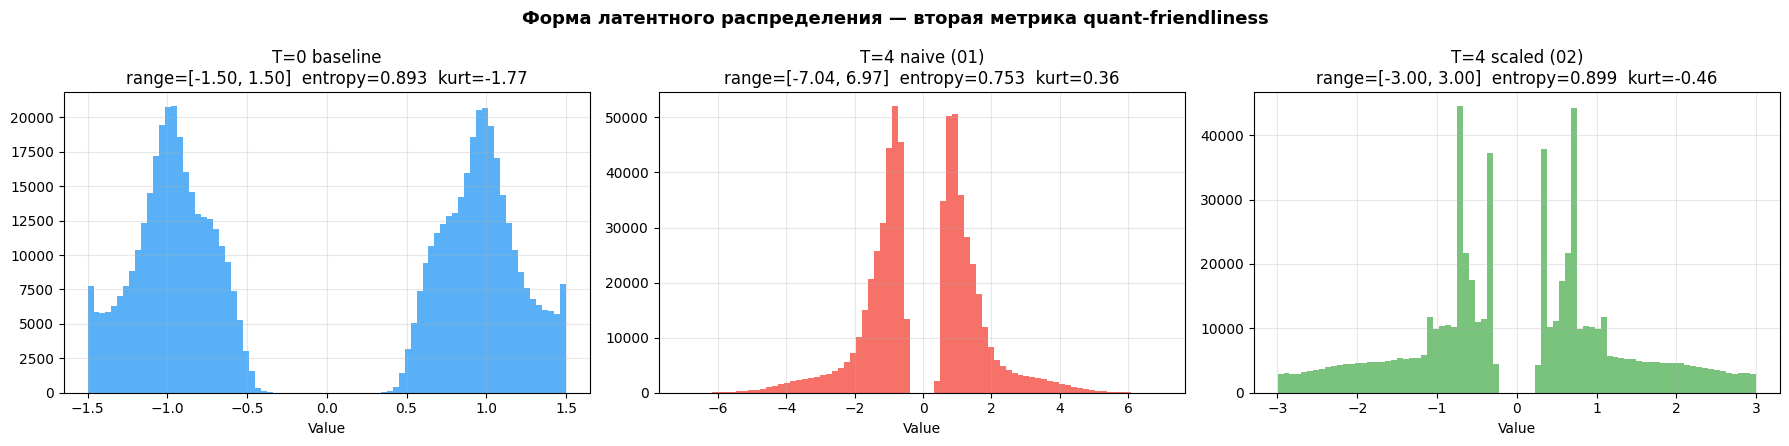

In [42]:
def dist_stats(x, nbins=80):
    hist, edges = np.histogram(x, bins=nbins, density=True)
    p = hist[hist > 0]
    p = p / p.sum()
    entropy = -np.sum(p * np.log(p))
    entropy_norm = entropy / np.log(nbins)
    kurt = float(sp_stats.kurtosis(x))
    return entropy_norm, kurt, (float(x.min()), float(x.max()))


configs = [
    ('T=0 baseline', nz_baseline, '#2196F3'),
    ('T=4 naive (01)', nz_naive4, '#F44336'),
    ('T=4 scaled (02)', nz_scaled4, '#4CAF50'),
]

print(f'{"Config":<20} {"Range":>20} {"Entropy_norm":>14} {"Kurtosis":>12}')
print('-' * 70)
dist_summary = {}
for name, lat, _ in configs:
    e, k, r = dist_stats(lat)
    dist_summary[name] = {'entropy_norm': e, 'kurtosis': k, 'range': r}
    print(f'{name:<20} [{r[0]:+6.2f},{r[1]:+6.2f}] {e:>14.4f} {k:>12.2f}')

print()
print('Читаем: entropy_norm близко к 1 = uniform (quant-friendly).')
print('        kurtosis близко к 0 = Gaussian-подобное, > 3 = heavy-tailed (плохо).')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (name, lat, color) in zip(axes, configs):
    ax.hist(lat, bins=80, color=color, alpha=0.75)
    ax.set_title(f'{name}\nrange=[{lat.min():.2f}, {lat.max():.2f}]  '
                 f'entropy={dist_summary[name]["entropy_norm"]:.3f}  '
                 f'kurt={dist_summary[name]["kurtosis"]:.2f}')
    ax.set_xlabel('Value')
    ax.grid(True, alpha=0.3)

plt.suptitle('Форма латентного распределения — вторая метрика quant-friendliness',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ARCH_DIR / 'looped_distribution_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Сохранение результатов

In [43]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

try:
    dist_analysis_out = dict(dist_summary)
except NameError:
    dist_analysis_out = {}

out = {
    'experiment': 'looped_chaos_scaled_residual_stage1b',
    'timestamp': ts,
    'proposition': 'Prop. 3: z_{t+1} = z_t + (1/T)·chaos(Wz+b) => |z_T| <= 2(1+w)',
    'theoretical_bound': THEOR_BOUND,
    'config': {
        'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE,
        'T_sweep': T_SWEEP, 'bits_sweep': BITS_SWEEP,
        'num_runs': NUM_RUNS, 'epochs': EPOCHS,
    },
    'results_01_naive_reference': results_01,
    'results': {str(T): results[T] for T in T_SWEEP},
    'summary': {str(T): {
        'val_loss_mean': summary[T]['val_loss'][0],
        'val_loss_std': summary[T]['val_loss'][1],
        'dead_pct': summary[T]['dead_pct'],
        'lat_var': summary[T]['lat_var'],
        'lat_range': summary[T]['range'],
        'bound_ok': summary[T]['bound_ok'],
        'degradation': summary[T]['deg'],
    } for T in T_SWEEP},
    'distribution_analysis': dist_analysis_out,
}

out_file = JSONS_DIR / f'looped_chaos_stage1b_scaled_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
print(f'Saved: {out_file}')


Saved: /Users/savenkovviktor/Documents/GitHub/k-sparse-chaos-autoencoder/jsons/looped_chaos_stage1b_scaled_20260424_020417.json


## 8. Вердикт и дальнейшие шаги

**Что смотрим в результатах выше:**

1. **Proposition 3 PASS/FAIL** — все ли T дают range в `[-3, 3]`? Если да → теория расширена корректно, можно формально добавлять в [proofs.md](../proofs.md)

2. **Loss: 02 vs 01.** Ожидаем: 02_loss ≈ baseline (0.17) для всех T. Если всё ещё сильно выше baseline → weight sharing + K-sparse всё равно мешают, нужна другая архитектура (gated update)

3. **2-bit degradation.** Если T>0 даёт deg ≤ 13% (1.3× baseline) → GO. Если 13-17% → YELLOW (можно улучшить tuning). Если >17% → NO-GO даже после фикса, идея не работает в этой форме

**Возможные исходы:**

- **Все зелёное** → Stage 2 (Sparse MoE с chaos-экспертами), proofs.md получает Proposition 3, параллельно готовим абляции без looped/MoE для статьи
- **Bound сохранён, но loss хуже baseline** → loops не приносят пользы, но и не ломают; делаем абляцию «с loops vs без» и либо удаляем looped (если нет пользы), либо пробуем gated update
- **Bound снова violated** → alpha = 1/T слишком агрессивно, delta подавляется, и модель либо не обучается, либо обходит scaling через большие веса Dense. Пробуем gated update (learnable scaling)